# Notebook 2 – Adult Income (Binary Classification)

## Overview
We benchmark six tabular-learning methods on the UCI Adult Income dataset:
**ResNet**, **FT-Transformer**, **XGBoost**, **LightGBM**, **Random Forest**,
and **Logistic Regression**.  
Each model is tuned with **Optuna** (20 trials) and evaluated across 3 seeds.  
Metrics: **Accuracy**, **AUC-ROC**, **F1**.


In [53]:
# !pip install pytorch-tabnet "rtdl==0.0.13" optuna xgboost lightgbm ucimlrepo scikit-learn pandas numpy matplotlib seaborn shap

Optuna

n_epochs = 50,
patience = 10

Final training

n_epochs = 100,
patience = 10

## Imports

In [54]:
import warnings
warnings.filterwarnings('ignore')

import random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from rtdl_revisiting_models import MLP, ResNet, FTTransformer
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo

from pytorch_tabnet.tab_model import TabNetClassifier

device_ = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device_}")


Using device: cpu


## Configuration

In [55]:
SEEDS           = [42, 123, 456]
N_OPTUNA_TRIALS = 20
TEST_SIZE       = 0.20
VAL_FRAC        = 0.25


## Data Loading & EDA

In [56]:
df = pd.read_csv("adult.csv", na_values=" ?", skipinitialspace=True)

X_raw = df.drop(columns=["income"]).copy()
y_raw = df[["income"]].copy()

print("Features shape:", X_raw.shape)
print()
print(X_raw.dtypes)
print()
print(X_raw.describe())


Features shape: (32561, 14)

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
dtype: object

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.0000

In [57]:
# Target distribution
target_series = y_raw.iloc[:, 0].astype(str).str.strip()
print("Unique target values:", target_series.unique())
print(target_series.value_counts())


Unique target values: ['<=50K' '>50K']
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


In [58]:
# Missing value overview
print("Missing values (including '?'):")
for col in X_raw.columns:
    n = (X_raw[col].astype(str).str.strip() == '?').sum()
    if n > 0:
        print(f"  {col}: {n}")


Missing values (including '?'):
  workclass: 1836
  occupation: 1843
  native-country: 583


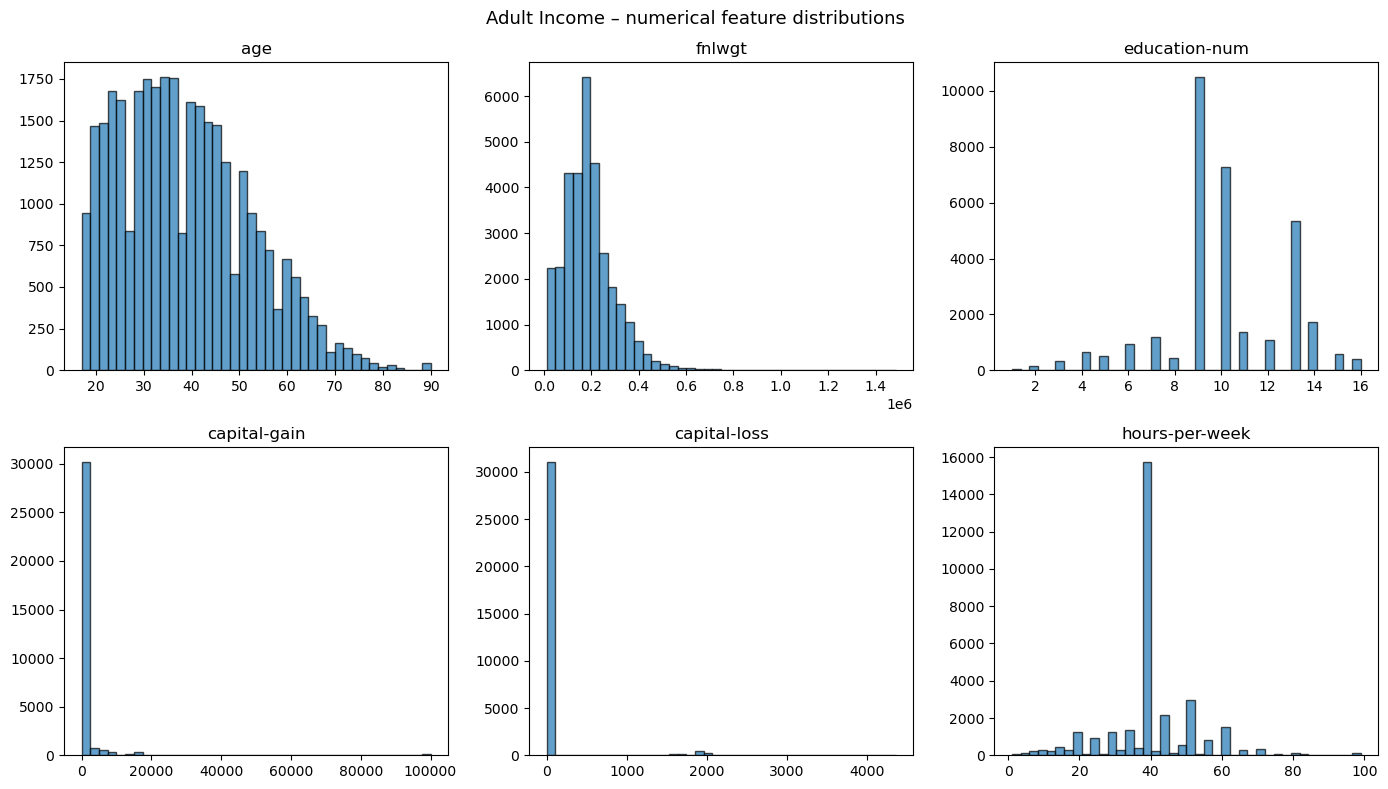

In [59]:
num_cols_eda = [
    'age', 'fnlwgt', 'education-num',
    'capital-gain', 'capital-loss', 'hours-per-week'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), num_cols_eda):
    ax.hist(X_raw[col].dropna(), bins=40, edgecolor='k', alpha=0.7)
    ax.set_title(col)
plt.suptitle("Adult Income – numerical feature distributions", fontsize=13)
plt.tight_layout()
plt.show()

## Preprocessing

In [60]:
# Raw columns
num_cols_raw = [
    'age', 'fnlwgt', 'education-num',
    'capital-gain', 'capital-loss', 'hours-per-week'
]

cat_cols = [
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
]

In [61]:
y_series = y_raw.iloc[:, 0].astype(str).str.strip().str.replace('.', '', regex=False)
y = np.where(y_series == '>50K', 1, 0).astype(np.int64)

print(f"Positive rate: {y.mean():.3%}")
print(pd.Series(y).value_counts())

Positive rate: 24.081%
0    24720
1     7841
Name: count, dtype: int64


In [62]:
X_proc = X_raw.copy()

# Replace '?' with NaN in categorical columns
for col in cat_cols:
    X_proc[col] = X_proc[col].astype(str).str.strip().replace('?', np.nan)

# Impute numeric columns with median
for col in num_cols_raw:
    X_proc[col] = X_proc[col].fillna(X_proc[col].median())

# Impute categorical columns with 'Unknown'
for col in cat_cols:
    X_proc[col] = X_proc[col].fillna('Unknown')

# Binary flags BEFORE log transform
X_proc['has_capital_gain'] = (X_proc['capital-gain'] > 0).astype(int)
X_proc['has_capital_loss'] = (X_proc['capital-loss'] > 0).astype(int)

# Log transform
X_proc['capital-gain'] = np.log1p(X_proc['capital-gain'])
X_proc['capital-loss'] = np.log1p(X_proc['capital-loss'])

# Drop fnlwgt
X_proc = X_proc.drop(columns=['fnlwgt'])

print("Missing after preprocessing:", X_proc.isnull().sum().sum())
print(X_proc.head())

Missing after preprocessing: 0
   age workclass     education  education-num marital-status  \
0   90   Unknown       HS-grad              9        Widowed   
1   82   Private       HS-grad              9        Widowed   
2   66   Unknown  Some-college             10        Widowed   
3   54   Private       7th-8th              4       Divorced   
4   41   Private  Some-college             10      Separated   

          occupation   relationship   race     sex  capital-gain  \
0            Unknown  Not-in-family  White  Female           0.0   
1    Exec-managerial  Not-in-family  White  Female           0.0   
2            Unknown      Unmarried  Black  Female           0.0   
3  Machine-op-inspct      Unmarried  White  Female           0.0   
4     Prof-specialty      Own-child  White  Female           0.0   

   capital-loss  hours-per-week native-country  has_capital_gain  \
0      8.379539              40  United-States                 0   
1      8.379539              18  United

In [63]:
# Define final column groups after preprocessing
num_cols_final = [
    'age', 'education-num', 'capital-gain',
    'capital-loss', 'hours-per-week',
    'has_capital_gain', 'has_capital_loss'
]

cat_cols_final = [
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
]


## Data Splitting (60 / 20 / 20)

In [64]:
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X_proc, y, test_size=0.4, random_state=42, stratify=y
)

X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train_df.shape, "Val:", X_val_df.shape, "Test:", X_test_df.shape)
print("y_train distribution:\n", pd.Series(y_train).value_counts(normalize=True))
print("y_val distribution:\n", pd.Series(y_val).value_counts(normalize=True))
print("y_test distribution:\n", pd.Series(y_test).value_counts(normalize=True))

Train: (19536, 15) Val: (6512, 15) Test: (6513, 15)
y_train distribution:
 0    0.759214
1    0.240786
Name: proportion, dtype: float64
y_val distribution:
 0    0.759214
1    0.240786
Name: proportion, dtype: float64
y_test distribution:
 0    0.759097
1    0.240903
Name: proportion, dtype: float64


In [65]:
# Classical models pipeline - logistics regression, random forest, xgboost, lightgbm

XX_train_c = pd.get_dummies(X_train_df, drop_first=True)
X_val_c = pd.get_dummies(X_val_df, drop_first=True)
X_test_c = pd.get_dummies(X_test_df, drop_first=True)

X_val_c = X_val_c.reindex(columns=X_train_c.columns, fill_value=0)
X_test_c = X_test_c.reindex(columns=X_train_c.columns, fill_value=0)

print("Classical shapes:")
print("Train:", X_train_c.shape)
print("Val:  ", X_val_c.shape)
print("Test: ", X_test_c.shape)

Classical shapes:
Train: (19536, 100)
Val:   (6512, 100)
Test:  (6513, 100)


In [66]:
# Deep learning pipeline ResNet, FT-Transformer

ord_enc = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train_cat = ord_enc.fit_transform(X_train_df[cat_cols_final]).astype(np.int64)
X_val_cat = ord_enc.transform(X_val_df[cat_cols_final]).astype(np.int64)
X_test_cat = ord_enc.transform(X_test_df[cat_cols_final]).astype(np.int64)

# Shift so unknown becomes 0
X_train_cat = X_train_cat + 1
X_val_cat = X_val_cat + 1
X_test_cat = X_test_cat + 1

cat_cardinalities = [len(categories) + 1 for categories in ord_enc.categories_]

scaler_num = StandardScaler()
X_train_num = scaler_num.fit_transform(X_train_df[num_cols_final].astype(np.float32)).astype(np.float32)
X_val_num = scaler_num.transform(X_val_df[num_cols_final].astype(np.float32)).astype(np.float32)
X_test_num = scaler_num.transform(X_test_df[num_cols_final].astype(np.float32)).astype(np.float32)

y_train_np = np.asarray(y_train).astype(np.int64)
y_val_np = np.asarray(y_val).astype(np.int64)
y_test_np = np.asarray(y_test).astype(np.int64)

print("Numeric shapes:")
print("Train:", X_train_num.shape)
print("Val:  ", X_val_num.shape)
print("Test: ", X_test_num.shape)

print("\nCategorical shapes:")
print("Train:", X_train_cat.shape)
print("Val:  ", X_val_cat.shape)
print("Test: ", X_test_cat.shape)

print("\nTarget shapes:")
print("Train:", y_train_np.shape)
print("Val:  ", y_val_np.shape)
print("Test: ", y_test_np.shape)

print("\nCategorical cardinalities:")
print(cat_cardinalities)

Numeric shapes:
Train: (19536, 7)
Val:   (6512, 7)
Test:  (6513, 7)

Categorical shapes:
Train: (19536, 8)
Val:   (6512, 8)
Test:  (6513, 8)

Target shapes:
Train: (19536,)
Val:   (6512,)
Test:  (6513,)

Categorical cardinalities:
[10, 17, 8, 16, 7, 6, 3, 42]


In [67]:
print("Min categorical value:", X_train_cat.min())
print("Max values by column:", X_train_cat.max(axis=0))
print("Any negative in cat?", (X_train_cat < 0).any())

print("Numeric dtype:", X_train_num.dtype)
print("Categorical dtype:", X_train_cat.dtype)
print("Target dtype:", y_train_np.dtype)
print("Target unique values:", np.unique(y_train_np))

Min categorical value: 1
Max values by column: [ 9 16  7 15  6  5  2 41]
Any negative in cat? False
Numeric dtype: float32
Categorical dtype: int64
Target dtype: int64
Target unique values: [0 1]


## Helper Functions

In [68]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def compute_classification_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return acc, auc, f1

def train_tabular_model(
    model,
    X_num_tr, X_cat_tr, y_tr,
    X_num_v, X_cat_v, y_v,
    lr=1e-3, n_epochs=100, batch_size=256,
    device_='cpu', patience=10,   # aligned with Yong Seng
    use_class_weight=True
):
    model = model.to(device_)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    if use_class_weight:
        pos_weight = (len(y_tr) - y_tr.sum()) / y_tr.sum()
        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=device_)
        )
    else:
        criterion = nn.BCEWithLogitsLoss()

    X_num_tr_t = torch.tensor(X_num_tr, dtype=torch.float32, device=device_)
    X_cat_tr_t = torch.tensor(X_cat_tr, dtype=torch.long, device=device_) if X_cat_tr is not None else None
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32, device=device_)

    X_num_v_t = torch.tensor(X_num_v, dtype=torch.float32, device=device_)
    X_cat_v_t = torch.tensor(X_cat_v, dtype=torch.long, device=device_) if X_cat_v is not None else None
    y_v_t = torch.tensor(y_v, dtype=torch.float32, device=device_)

    train_losses, val_losses = [], []
    best_val = float('inf')
    best_state = None
    pat_cnt = 0

    for epoch in range(n_epochs):
        model.train()
        n = len(X_num_tr_t)
        idx = torch.randperm(n, device=device_)
        ep_loss = 0.0

        for i in range(0, n, batch_size):
            b = idx[i:i + batch_size]
            xn = X_num_tr_t[b]
            xc = X_cat_tr_t[b] if X_cat_tr_t is not None else None
            yb = y_tr_t[b]

            optimizer.zero_grad()
            out = model(xn, xc).squeeze(-1)
            loss = criterion(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            ep_loss += loss.item() * len(b)

        model.eval()
        with torch.no_grad():
            vout = model(X_num_v_t, X_cat_v_t).squeeze(-1)
            vloss = criterion(vout, y_v_t).item()

        train_losses.append(ep_loss / n)
        val_losses.append(vloss)

        if vloss < best_val:
            best_val = vloss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            pat_cnt = 0
        else:
            pat_cnt += 1

        if pat_cnt >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses

def predict_tabular_model(model, X_num, X_cat, device_, batch_size=512):
    model.eval()
    model = model.to(device_)

    X_num_t = torch.tensor(X_num, dtype=torch.float32, device=device_)
    X_cat_t = torch.tensor(X_cat, dtype=torch.long, device=device_) if X_cat is not None else None

    logits, probs = [], []

    with torch.no_grad():
        for i in range(0, len(X_num_t), batch_size):
            xn = X_num_t[i:i + batch_size]
            xc = X_cat_t[i:i + batch_size] if X_cat_t is not None else None

            out = model(xn, xc).squeeze(-1)
            pr = torch.sigmoid(out)

            logits.append(out.cpu().numpy())
            probs.append(pr.cpu().numpy())

    logits = np.concatenate(logits)
    probs = np.concatenate(probs)
    preds = (probs >= 0.5).astype(int)

    return logits, probs, preds


## Model 1: ResNet

In [69]:
all_results = []

In [70]:
class ResidualBlock(nn.Module):
    def __init__(self, d_hidden, dropout=0.2):
        super().__init__()
        self.bn1 = nn.BatchNorm1d(d_hidden)
        self.fc1 = nn.Linear(d_hidden, d_hidden)
        self.relu = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.bn2 = nn.BatchNorm1d(d_hidden)
        self.fc2 = nn.Linear(d_hidden, d_hidden)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x):
        residual = x

        out = self.bn1(x)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.drop1(out)

        out = self.bn2(out)
        out = self.fc2(out)
        out = self.drop2(out)

        return residual + out

class TabularResNet(nn.Module):
    def __init__(
        self,
        n_num_features,
        cat_cardinalities,
        d_embedding=16,
        d_hidden=256,
        n_blocks=3,
        dropout=0.2
    ):
        super().__init__()

        self.has_cat = cat_cardinalities is not None and len(cat_cardinalities) > 0

        if self.has_cat:
            self.cat_embeddings = nn.ModuleList([
                nn.Embedding(cardinality, d_embedding)
                for cardinality in cat_cardinalities
            ])
            cat_dim = len(cat_cardinalities) * d_embedding
        else:
            self.cat_embeddings = None
            cat_dim = 0

        input_dim = n_num_features + cat_dim

        self.input_layer = nn.Linear(input_dim, d_hidden)
        self.input_bn = nn.BatchNorm1d(d_hidden)
        self.input_relu = nn.ReLU()
        self.input_drop = nn.Dropout(dropout)

        self.blocks = nn.Sequential(*[
            ResidualBlock(d_hidden=d_hidden, dropout=dropout)
            for _ in range(n_blocks)
        ])

        self.head_bn = nn.BatchNorm1d(d_hidden)
        self.head_relu = nn.ReLU()
        self.head_drop = nn.Dropout(dropout)
        self.output_layer = nn.Linear(d_hidden, 1)

    def forward(self, x_num, x_cat=None):
        if self.has_cat and x_cat is not None:
            cat_embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)]
            x_cat_emb = torch.cat(cat_embs, dim=1)
            x = torch.cat([x_num, x_cat_emb], dim=1)
        else:
            x = x_num

        x = self.input_layer(x)
        x = self.input_bn(x)
        x = self.input_relu(x)
        x = self.input_drop(x)

        x = self.blocks(x)

        x = self.head_bn(x)
        x = self.head_relu(x)
        x = self.head_drop(x)

        logits = self.output_layer(x)
        return logits

def resnet_clf_objective(trial):
    d_embedding = trial.suggest_categorical("d_embedding", [8, 16, 24, 32])
    d_hidden = trial.suggest_categorical("d_hidden", [64, 128, 256, 512])
    n_blocks = trial.suggest_int("n_blocks", 2, 6)
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])

    set_seed(42)

    model = TabularResNet(
        n_num_features=X_train_num.shape[1],
        cat_cardinalities=cat_cardinalities,
        d_embedding=d_embedding,
        d_hidden=d_hidden,
        n_blocks=n_blocks,
        dropout=dropout
    )

    model, _, _ = train_tabular_model(
        model=model,
        X_num_tr=X_train_num,
        X_cat_tr=X_train_cat,
        y_tr=y_train_np,
        X_num_v=X_val_num,
        X_cat_v=X_val_cat,
        y_v=y_val_np,
        lr=lr,
        n_epochs=50, # align with Yong Seng
        batch_size=batch_size,
        device_=device_,
        patience=10,   # aligned with Yong Seng
        use_class_weight=True
    )

    _, val_probs, _ = predict_tabular_model(
        model,
        X_val_num,
        X_val_cat,
        device_=device_
    )

    return roc_auc_score(y_val_np, val_probs)

study_resnet = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_resnet.optimize(resnet_clf_objective, n_trials=N_OPTUNA_TRIALS)

best_resnet = study_resnet.best_params
print("\nBest ResNet params:")
print(best_resnet)



Best ResNet params:
{'d_embedding': 8, 'd_hidden': 128, 'n_blocks': 5, 'dropout': 0.39897619511599725, 'lr': 0.00043182000751369986, 'batch_size': 512}


In [71]:
print("\nTraining ResNet across seeds...")

for seed in SEEDS:
    set_seed(seed)

    model = TabularResNet(
        n_num_features=X_train_num.shape[1],
        cat_cardinalities=cat_cardinalities,
        d_embedding=best_resnet["d_embedding"],
        d_hidden=best_resnet["d_hidden"],
        n_blocks=best_resnet["n_blocks"],
        dropout=best_resnet["dropout"]
    )

    model, train_losses, val_losses = train_tabular_model(
        model=model,
        X_num_tr=X_train_num,
        X_cat_tr=X_train_cat,
        y_tr=y_train_np,
        X_num_v=X_val_num,
        X_cat_v=X_val_cat,
        y_v=y_val_np,
        lr=best_resnet["lr"],
        n_epochs=100,
        batch_size=best_resnet["batch_size"],
        device_=device_,
        patience=10,   # aligned with Yong Seng
        use_class_weight=True
    )

    _, test_probs, test_preds = predict_tabular_model(
        model,
        X_test_num,
        X_test_cat,
        device_=device_
    )

    acc, auc, f1 = compute_classification_metrics(
        y_test_np, test_preds, test_probs
    )

    all_results.append({
        "method": "ResNet",
        "seed": seed,
        "accuracy": acc,
        "auc": auc,
        "f1": f1
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")



Training ResNet across seeds...
Seed 42: Acc=0.7897, AUC=0.9046, F1=0.6686
Seed 123: Acc=0.7883, AUC=0.9026, F1=0.6665
Seed 456: Acc=0.7915, AUC=0.9032, F1=0.6686


In [72]:
results_resnet = pd.DataFrame([r for r in all_results if r["method"] == "ResNet"])

print("\nPer-seed ResNet results:")
print(results_resnet)

print("\nResNet mean performance:")
print(results_resnet[["accuracy", "auc", "f1"]].mean())

print("\nResNet std performance:")
print(results_resnet[["accuracy", "auc", "f1"]].std())


Per-seed ResNet results:
   method  seed  accuracy       auc        f1
0  ResNet    42  0.789651  0.904629  0.668602
1  ResNet   123  0.788270  0.902613  0.666505
2  ResNet   456  0.791494  0.903219  0.668619

ResNet mean performance:
accuracy    0.789805
auc         0.903487
f1          0.667909
dtype: float64

ResNet std performance:
accuracy    0.001618
auc         0.001035
f1          0.001215
dtype: float64


## Model 2: FT-Transformer

In [73]:
# FT-Transformer tuning

n_num_ft = X_train_num.shape[1]

def ft_clf_objective(trial):
    d_block = trial.suggest_categorical('d_block', [128, 192, 256])
    n_blocks = trial.suggest_int('n_blocks', 1, 3)
    attention_dropout = trial.suggest_float('attention_dropout', 0.0, 0.3)
    ffn_dropout = trial.suggest_float('ffn_dropout', 0.0, 0.3)
    lr = trial.suggest_float('lr', 1e-4, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])

    set_seed(42)

    model = FTTransformer(
        n_cont_features=n_num_ft,
        cat_cardinalities=cat_cardinalities,
        d_out=1,
        n_blocks=n_blocks,
        d_block=d_block,
        attention_n_heads=8,
        attention_dropout=attention_dropout,
        ffn_d_hidden_multiplier=4/3,
        ffn_dropout=ffn_dropout,
        residual_dropout=0.0,
    )

    model, _, _ = train_tabular_model(
        model=model,
        X_num_tr=X_train_num,
        X_cat_tr=X_train_cat,
        y_tr=y_train_np,
        X_num_v=X_val_num,
        X_cat_v=X_val_cat,
        y_v=y_val_np,
        lr=lr,
        n_epochs=50, # align with Yong Seng
        batch_size=batch_size,
        device_=device_,
        patience=10,
        use_class_weight=True
    )

    _, val_probs, _ = predict_tabular_model(
        model=model,
        X_num=X_val_num,
        X_cat=X_val_cat,
        device_=device_
    )

    return roc_auc_score(y_val_np, val_probs)


study_ft = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_ft.optimize(ft_clf_objective, n_trials=N_OPTUNA_TRIALS)

best_ft = study_ft.best_params
print("\nBest FT-Transformer params:")
print(best_ft)


Best FT-Transformer params:
{'d_block': 192, 'n_blocks': 1, 'attention_dropout': 0.009269396014095928, 'ffn_dropout': 0.0031900000168767696, 'lr': 0.00035298891823418713, 'batch_size': 128}


In [96]:
print("\nTraining FT-Transformer across seeds...")

ft_train_curves = {}

for seed in SEEDS:
    set_seed(seed)

    model = FTTransformer(
        n_cont_features=n_num_ft,
        cat_cardinalities=cat_cardinalities,
        d_out=1,
        n_blocks=best_ft['n_blocks'],
        d_block=best_ft['d_block'],
        attention_n_heads=8,
        attention_dropout=best_ft['attention_dropout'],
        ffn_d_hidden_multiplier=4/3,
        ffn_dropout=best_ft['ffn_dropout'],
        residual_dropout=0.0,
    )

    model, train_losses, val_losses = train_tabular_model(
        model=model,
        X_num_tr=X_train_num,
        X_cat_tr=X_train_cat,
        y_tr=y_train_np,
        X_num_v=X_val_num,
        X_cat_v=X_val_cat,
        y_v=y_val_np,
        lr=best_ft['lr'],
        n_epochs=100,
        batch_size=best_ft['batch_size'],
        device_=device_,
        patience=10,
        use_class_weight=True
    )

    # Save curves for plotting later
    ft_train_curves[seed] = (train_losses, val_losses)

    _, test_probs, test_preds = predict_tabular_model(
        model=model,
        X_num=X_test_num,
        X_cat=X_test_cat,
        device_=device_
    )

    acc, auc, f1 = compute_classification_metrics(
        y_test_np, test_preds, test_probs
    )

    all_results.append({
        'method': 'FT-Transformer',
        'seed': seed,
        'accuracy': acc,
        'auc': auc,
        'f1': f1
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")


Training FT-Transformer across seeds...
Seed 42: Acc=0.8121, AUC=0.9105, F1=0.6870
Seed 123: Acc=0.8101, AUC=0.9100, F1=0.6847
Seed 456: Acc=0.7927, AUC=0.9096, F1=0.6714


In [75]:
results_ft = pd.DataFrame([r for r in all_results if r['method'] == 'FT-Transformer'])

print("\nPer-seed FT-Transformer results:")
print(results_ft)

print("\nFT-Transformer mean performance:")
print(results_ft[['accuracy', 'auc', 'f1']].mean())

print("\nFT-Transformer std performance:")
print(results_ft[['accuracy', 'auc', 'f1']].std())


Per-seed FT-Transformer results:
           method  seed  accuracy       auc        f1
0  FT-Transformer    42  0.812068  0.910532  0.686957
1  FT-Transformer   123  0.810072  0.910041  0.684680
2  FT-Transformer   456  0.792722  0.909636  0.671373

FT-Transformer mean performance:
accuracy    0.804954
auc         0.910070
f1          0.681003
dtype: float64

FT-Transformer std performance:
accuracy    0.010640
auc         0.000449
f1          0.008417
dtype: float64


## Model 3: XGBoost

In [76]:
# Class imbalance ratio
scale_pos_weight_base = (y_train_np == 0).sum() / (y_train_np == 1).sum()
print("Base scale_pos_weight:", scale_pos_weight_base)


def xgb_clf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float(
            'scale_pos_weight',
            max(1.0, scale_pos_weight_base * 0.7),
            scale_pos_weight_base * 1.3
        ),
        'random_state': 42,
        'eval_metric': 'auc',
        'verbosity': 0,
        'tree_method': 'hist'
    }

    set_seed(42)

    model = xgb.XGBClassifier(**params)
    model.fit(X_train_c, y_train_np)

    val_probs = model.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val_np, val_probs)


study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_xgb.optimize(xgb_clf_objective, n_trials=N_OPTUNA_TRIALS)

best_xgb = study_xgb.best_params
print("\nBest XGBoost params:")
print(best_xgb)

Base scale_pos_weight: 3.1530612244897958

Best XGBoost params:
{'n_estimators': 452, 'max_depth': 5, 'learning_rate': 0.03416349944524313, 'subsample': 0.7799465042658286, 'colsample_bytree': 0.7488645104787093, 'min_child_weight': 1, 'gamma': 4.2942775256585985, 'reg_alpha': 1.2722974438529106e-08, 'reg_lambda': 0.013425608609788007, 'scale_pos_weight': 3.6728204762909913}


In [77]:
print("Training XGBoost across seeds...")

for seed in SEEDS:
    set_seed(seed)

    model = xgb.XGBClassifier(
        n_estimators=best_xgb['n_estimators'],
        max_depth=best_xgb['max_depth'],
        learning_rate=best_xgb['learning_rate'],
        subsample=best_xgb['subsample'],
        colsample_bytree=best_xgb['colsample_bytree'],
        min_child_weight=best_xgb['min_child_weight'],
        gamma=best_xgb['gamma'],
        reg_alpha=best_xgb['reg_alpha'],
        reg_lambda=best_xgb['reg_lambda'],
        scale_pos_weight=best_xgb['scale_pos_weight'],
        random_state=seed,
        eval_metric='auc',
        verbosity=0,
        tree_method='hist'
    )

    model.fit(X_train_c, y_train_np)

    preds = model.predict(X_test_c)
    probs = model.predict_proba(X_test_c)[:, 1]

    acc, auc, f1 = compute_classification_metrics(y_test_np, preds, probs)

    all_results.append({
        'method': 'XGBoost',
        'seed': seed,
        'accuracy': acc,
        'auc': auc,
        'f1': f1
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

Training XGBoost across seeds...
Seed 42: Acc=0.8217, AUC=0.9256, F1=0.7024
Seed 123: Acc=0.8240, AUC=0.9257, F1=0.7051
Seed 456: Acc=0.8227, AUC=0.9257, F1=0.7033


In [78]:
results_xgb = pd.DataFrame([r for r in all_results if r['method'] == 'XGBoost'])

print("\nPer-seed XGBoost results:")
print(results_xgb)

print("\nXGBoost mean performance:")
print(results_xgb[['accuracy', 'auc', 'f1']].mean())

print("\nXGBoost std performance:")
print(results_xgb[['accuracy', 'auc', 'f1']].std())


Per-seed XGBoost results:
    method  seed  accuracy       auc        f1
0  XGBoost    42  0.821741  0.925632  0.702384
1  XGBoost   123  0.824044  0.925671  0.705095
2  XGBoost   456  0.822662  0.925693  0.703314

XGBoost mean performance:
accuracy    0.822816
auc         0.925665
f1          0.703598
dtype: float64

XGBoost std performance:
accuracy    0.001159
auc         0.000031
f1          0.001378
dtype: float64


## Model 4: LightGBM

In [79]:
# Class imbalance ratio
scale_pos_weight_base = (y_train_np == 0).sum() / (y_train_np == 1).sum()
print("Base scale_pos_weight:", scale_pos_weight_base)


def lgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float(
            'scale_pos_weight',
            max(1.0, scale_pos_weight_base * 0.7),
            scale_pos_weight_base * 1.3
        ),
        'objective': 'binary',
        'metric': 'auc',
        'random_state': 42,
        'verbosity': -1,
        'n_jobs': -1
    }

    set_seed(42)

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_c, y_train_np)

    val_probs = model.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val_np, val_probs)


study_lgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_lgb.optimize(lgb_objective, n_trials=N_OPTUNA_TRIALS)

best_lgb = study_lgb.best_params
print("\nBest LightGBM params:")
print(best_lgb)

Base scale_pos_weight: 3.1530612244897958

Best LightGBM params:
{'n_estimators': 478, 'num_leaves': 20, 'learning_rate': 0.02847748683027988, 'subsample': 0.751180619986081, 'colsample_bytree': 0.8144754354791038, 'min_child_samples': 32, 'reg_alpha': 1.368174031940222e-08, 'reg_lambda': 0.003327054963436224, 'scale_pos_weight': 2.2968016075731468}


In [80]:
print("Training LightGBM across seeds...")

for seed in SEEDS:
    set_seed(seed)

    model = lgb.LGBMClassifier(
        n_estimators=best_lgb['n_estimators'],
        num_leaves=best_lgb['num_leaves'],
        learning_rate=best_lgb['learning_rate'],
        subsample=best_lgb['subsample'],
        colsample_bytree=best_lgb['colsample_bytree'],
        min_child_samples=best_lgb['min_child_samples'],
        reg_alpha=best_lgb['reg_alpha'],
        reg_lambda=best_lgb['reg_lambda'],
        scale_pos_weight=best_lgb['scale_pos_weight'],
        objective='binary',
        metric='auc',
        random_state=seed,
        verbosity=-1,
        n_jobs=-1
    )

    model.fit(X_train_c, y_train_np)

    preds = model.predict(X_test_c)
    probs = model.predict_proba(X_test_c)[:, 1]

    acc, auc, f1 = compute_classification_metrics(y_test_np, preds, probs)

    all_results.append({
        'method': 'LightGBM',
        'seed': seed,
        'accuracy': acc,
        'auc': auc,
        'f1': f1
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

Training LightGBM across seeds...
Seed 42: Acc=0.8475, AUC=0.9261, F1=0.7205
Seed 123: Acc=0.8472, AUC=0.9262, F1=0.7211
Seed 456: Acc=0.8474, AUC=0.9260, F1=0.7209


In [81]:
results_lgb = pd.DataFrame([r for r in all_results if r['method'] == 'LightGBM'])

print("\nPer-seed LightGBM results:")
print(results_lgb)

print("\nLightGBM mean performance:")
print(results_lgb[['accuracy', 'auc', 'f1']].mean())

print("\nLightGBM std performance:")
print(results_lgb[['accuracy', 'auc', 'f1']].std())


Per-seed LightGBM results:
     method  seed  accuracy       auc        f1
0  LightGBM    42  0.847536  0.926116  0.720518
1  LightGBM   123  0.847229  0.926197  0.721054
2  LightGBM   456  0.847382  0.925999  0.720943

LightGBM mean performance:
accuracy    0.847382
auc         0.926104
f1          0.720838
dtype: float64

LightGBM std performance:
accuracy    0.000154
auc         0.000099
f1          0.000283
dtype: float64


## Model 5: Random Forest

In [82]:
def rf_clf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None]),
        'random_state': 42,
        'n_jobs': -1
    }

    set_seed(42)

    model = RandomForestClassifier(**params)
    model.fit(X_train_c, y_train_np)

    val_probs = model.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val_np, val_probs)


study_rf = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_rf.optimize(rf_clf_objective, n_trials=N_OPTUNA_TRIALS)

best_rf = study_rf.best_params
print("\nBest RF params:")
print(best_rf)


Best RF params:
{'n_estimators': 352, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': None, 'class_weight': None}


In [83]:
print("Training Random Forest across seeds...")

for seed in SEEDS:
    set_seed(seed)

    model = RandomForestClassifier(
        n_estimators=best_rf['n_estimators'],
        max_depth=best_rf['max_depth'],
        min_samples_split=best_rf['min_samples_split'],
        min_samples_leaf=best_rf['min_samples_leaf'],
        max_features=best_rf['max_features'],
        class_weight=best_rf['class_weight'],
        random_state=seed,
        n_jobs=-1
    )

    model.fit(X_train_c, y_train_np)

    preds = model.predict(X_test_c)
    probs = model.predict_proba(X_test_c)[:, 1]

    acc, auc, f1 = compute_classification_metrics(y_test_np, preds, probs)

    all_results.append({
        'method': 'RandomForest',
        'seed': seed,
        'accuracy': acc,
        'auc': auc,
        'f1': f1
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

Training Random Forest across seeds...
Seed 42: Acc=0.8615, AUC=0.9160, F1=0.6826
Seed 123: Acc=0.8626, AUC=0.9162, F1=0.6854
Seed 456: Acc=0.8637, AUC=0.9153, F1=0.6882


In [84]:
results_rf = pd.DataFrame([r for r in all_results if r['method'] == 'RandomForest'])

print("\nPer-seed Random Forest results:")
print(results_rf)

print("\nRandom Forest mean performance:")
print(results_rf[['accuracy', 'auc', 'f1']].mean())

print("\nRandom Forest std performance:")
print(results_rf[['accuracy', 'auc', 'f1']].std())


Per-seed Random Forest results:
         method  seed  accuracy       auc        f1
0  RandomForest    42  0.861508  0.916031  0.682618
1  RandomForest   123  0.862583  0.916170  0.685413
2  RandomForest   456  0.863657  0.915330  0.688202

Random Forest mean performance:
accuracy    0.862583
auc         0.915844
f1          0.685411
dtype: float64

Random Forest std performance:
accuracy    0.001075
auc         0.000450
f1          0.002792
dtype: float64


## Model 6: Logistic Regression

In [85]:
def lr_objective(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10.0, log=True),
        'penalty': 'l2',
        'solver': 'liblinear',  # stable for small/medium data
        'class_weight': trial.suggest_categorical(
            'class_weight', ['balanced', None]
        ),
        'max_iter': 1000,
        'random_state': 42
    }

    set_seed(42)

    model = LogisticRegression(**params)
    model.fit(X_train_c, y_train_np)

    val_probs = model.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val_np, val_probs)


study_lr = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_lr.optimize(lr_objective, n_trials=N_OPTUNA_TRIALS)

best_lr = study_lr.best_params
print("\nBest Logistic Regression params:")
print(best_lr)


Best Logistic Regression params:
{'C': 9.778807767799925, 'class_weight': 'balanced'}


In [86]:
print("Training Logistic Regression across seeds...")

for seed in SEEDS:
    set_seed(seed)

    model = LogisticRegression(
        C=best_lr['C'],
        penalty='l2',
        solver='liblinear',
        class_weight=best_lr['class_weight'],
        max_iter=1000,
        random_state=seed
    )

    model.fit(X_train_c, y_train_np)

    preds = model.predict(X_test_c)
    probs = model.predict_proba(X_test_c)[:, 1]

    acc, auc, f1 = compute_classification_metrics(
        y_test_np, preds, probs
    )

    all_results.append({
        'method': 'LogisticRegression',
        'seed': seed,
        'accuracy': acc,
        'auc': auc,
        'f1': f1
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

Training Logistic Regression across seeds...
Seed 42: Acc=0.8072, AUC=0.9052, F1=0.6765
Seed 123: Acc=0.8072, AUC=0.9052, F1=0.6765
Seed 456: Acc=0.8072, AUC=0.9052, F1=0.6765


In [87]:
results_lr = pd.DataFrame([r for r in all_results if r['method'] == 'LogisticRegression'])

print("\nPer-seed Logistic Regression results:")
print(results_lr)

print("\nLogistic Regression mean performance:")
print(results_lr[['accuracy', 'auc', 'f1']].mean())

print("\nLogistic Regression std performance:")
print(results_lr[['accuracy', 'auc', 'f1']].std())


Per-seed Logistic Regression results:
               method  seed  accuracy       auc        f1
0  LogisticRegression    42  0.807155  0.905206  0.676455
1  LogisticRegression   123  0.807155  0.905206  0.676455
2  LogisticRegression   456  0.807155  0.905206  0.676455

Logistic Regression mean performance:
accuracy    0.807155
auc         0.905206
f1          0.676455
dtype: float64

Logistic Regression std performance:
accuracy    1.359740e-16
auc         0.000000e+00
f1          1.359740e-16
dtype: float64


## Results

In [88]:
df_res = pd.DataFrame(all_results)

summary = df_res.groupby('method').agg(
    acc_mean=('accuracy', 'mean'), acc_std=('accuracy', 'std'),
    auc_mean=('auc', 'mean'),      auc_std=('auc', 'std'),
    f1_mean=('f1', 'mean'),        f1_std=('f1', 'std')
)

summary['Accuracy'] = summary.apply(
    lambda x: f"{x['acc_mean']:.4f} ± {x['acc_std']:.4f}", axis=1
)
summary['AUC-ROC'] = summary.apply(
    lambda x: f"{x['auc_mean']:.4f} ± {x['auc_std']:.4f}", axis=1
)
summary['F1'] = summary.apply(
    lambda x: f"{x['f1_mean']:.4f} ± {x['f1_std']:.4f}", axis=1
)

summary_sorted = summary.sort_values(by='auc_mean', ascending=False)

final_table = summary_sorted[['Accuracy', 'AUC-ROC', 'F1']]

print("\nFinal Model Comparison:")
print(final_table)


Final Model Comparison:
                           Accuracy          AUC-ROC               F1
method                                                               
LightGBM            0.8474 ± 0.0002  0.9261 ± 0.0001  0.7208 ± 0.0003
XGBoost             0.8228 ± 0.0012  0.9257 ± 0.0000  0.7036 ± 0.0014
RandomForest        0.8626 ± 0.0011  0.9158 ± 0.0005  0.6854 ± 0.0028
FT-Transformer      0.8050 ± 0.0106  0.9101 ± 0.0004  0.6810 ± 0.0084
LogisticRegression  0.8072 ± 0.0000  0.9052 ± 0.0000  0.6765 ± 0.0000
ResNet              0.7898 ± 0.0016  0.9035 ± 0.0010  0.6679 ± 0.0012


## Visualizations

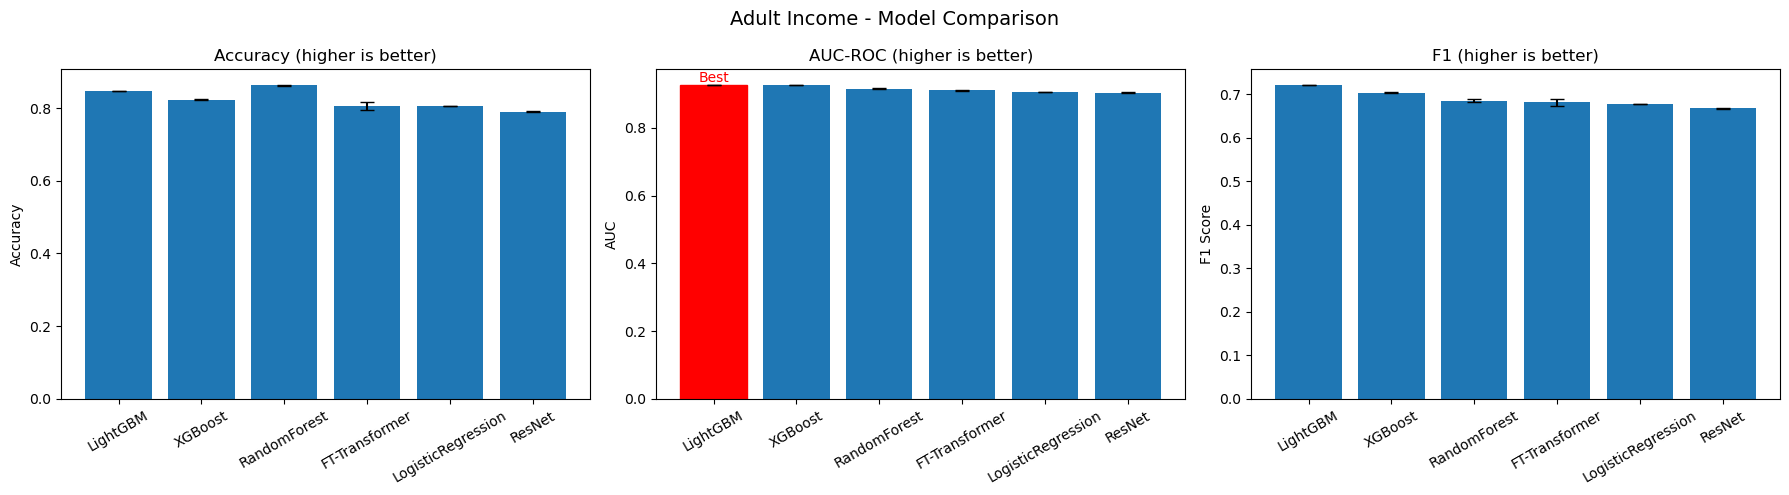

In [89]:
methods = ['LightGBM', 'XGBoost', 'RandomForest',
           'FT-Transformer', 'LogisticRegression', 'ResNet']

summary = summary.reindex(methods).dropna()
methods_plot = summary.index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].bar(methods_plot,
            summary['acc_mean'],
            yerr=summary['acc_std'],
            capsize=5)
axes[0].set_title('Accuracy (higher is better)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Accuracy')

# AUC
axes[1].bar(methods_plot,
            summary['auc_mean'],
            yerr=summary['auc_std'],
            capsize=5)
axes[1].set_title('AUC-ROC (higher is better)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylabel('AUC')

# F1
axes[2].bar(methods_plot,
            summary['f1_mean'],
            yerr=summary['f1_std'],
            capsize=5)
axes[2].set_title('F1 (higher is better)')
axes[2].tick_params(axis='x', rotation=30)
axes[2].set_ylabel('F1 Score')

# Highlight best AUC
best_idx = summary['auc_mean'].idxmax()
best_pos = summary.index.get_loc(best_idx)

axes[1].patches[best_pos].set_color('red')

offset = 0.01 * summary['auc_mean'].max()
axes[1].text(
    best_pos,
    summary.loc[best_idx, 'auc_mean'] + offset,
    'Best',
    ha='center',
    color='red',
    fontsize=10
)

plt.suptitle('Adult Income - Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()

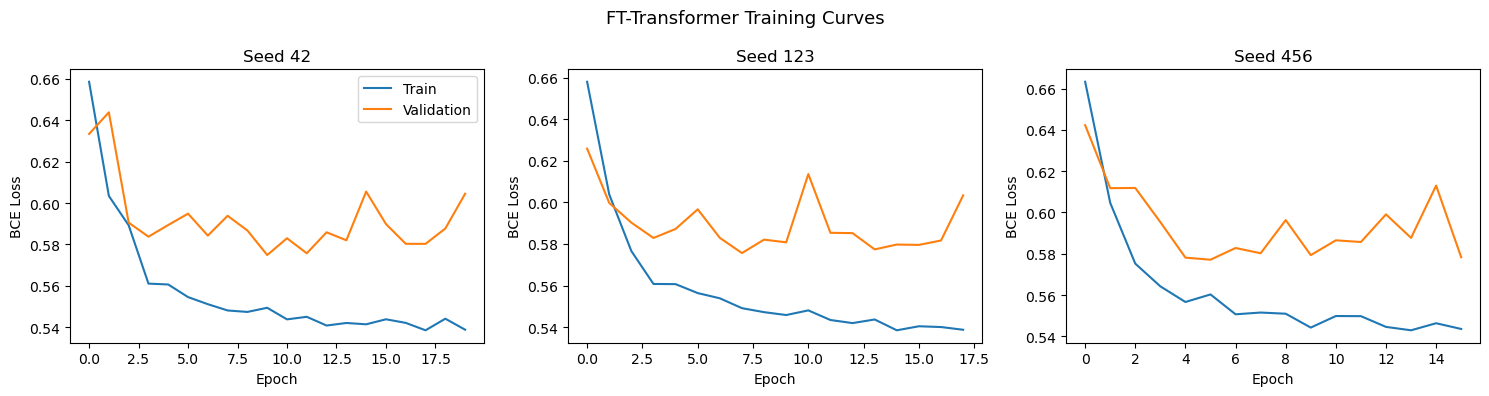

In [97]:
# FT-Transformer training curves

n_seeds = len(SEEDS)
fig, axes = plt.subplots(1, n_seeds, figsize=(5 * n_seeds, 4))

# Ensure axes is iterable even for 1 seed
if n_seeds == 1:
    axes = [axes]

for ax, seed in zip(axes, SEEDS):
    tr_l, va_l = ft_train_curves[seed]

    ax.plot(tr_l, label='Train')
    ax.plot(va_l, label='Validation')

    ax.set_title(f'Seed {seed}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')

# Single legend (cleaner)
axes[0].legend()

plt.suptitle('FT-Transformer Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

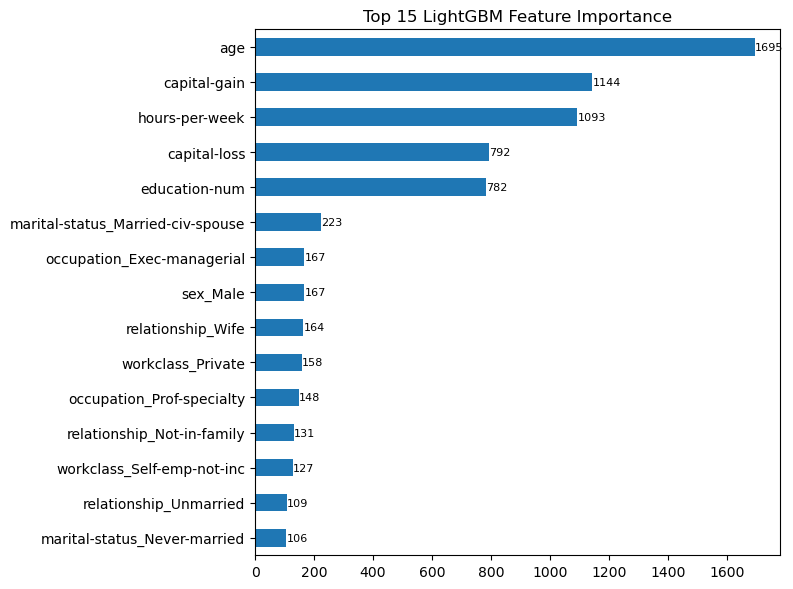

In [95]:
# Top 15 LightGBM feature importance
if 'lgb_model_last' in globals() and lgb_model_last is not None:

    fi_df = pd.DataFrame({
        'feature': X_train_c.columns,
        'importance': lgb_model_last.feature_importances_
    })

    # Get top 15
    fi_df = fi_df.sort_values('importance', ascending=False).head(15)

    # Reverse for horizontal plot
    fi_df = fi_df.sort_values('importance', ascending=True)

    ax = fi_df.plot.barh(
        x='feature',
        y='importance',
        figsize=(8, 6),
        legend=False
    )

    # Add value labels
    for i, v in enumerate(fi_df['importance']):
        ax.text(v, i, f"{v:.0f}", va='center', fontsize=8)

    plt.title('Top 15 LightGBM Feature Importance')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

In [93]:
best_seed = max(
    [r for r in all_results if r['method'] == 'LightGBM'],
    key=lambda x: x['auc']
)['seed']

print("Best LightGBM seed based on AUC:", best_seed)

set_seed(best_seed)

lgb_model_last = lgb.LGBMClassifier(
    n_estimators=best_lgb['n_estimators'],
    num_leaves=best_lgb['num_leaves'],
    learning_rate=best_lgb['learning_rate'],
    subsample=best_lgb['subsample'],
    colsample_bytree=best_lgb['colsample_bytree'],
    min_child_samples=best_lgb['min_child_samples'],
    reg_alpha=best_lgb['reg_alpha'],
    reg_lambda=best_lgb['reg_lambda'],
    scale_pos_weight=best_lgb['scale_pos_weight'],
    objective='binary',
    metric='auc',
    random_state=best_seed,
    verbosity=-1,
    n_jobs=-1
)

lgb_model_last.fit(X_train_c, y_train_np)

Best LightGBM seed based on AUC: 123


LGBMClassifier(colsample_bytree=0.8144754354791038,
               learning_rate=0.02847748683027988, metric='auc',
               min_child_samples=32, n_estimators=478, n_jobs=-1, num_leaves=20,
               objective='binary', random_state=123,
               reg_alpha=1.368174031940222e-08, reg_lambda=0.003327054963436224,
               scale_pos_weight=2.2968016075731468, subsample=0.751180619986081,
               verbosity=-1)

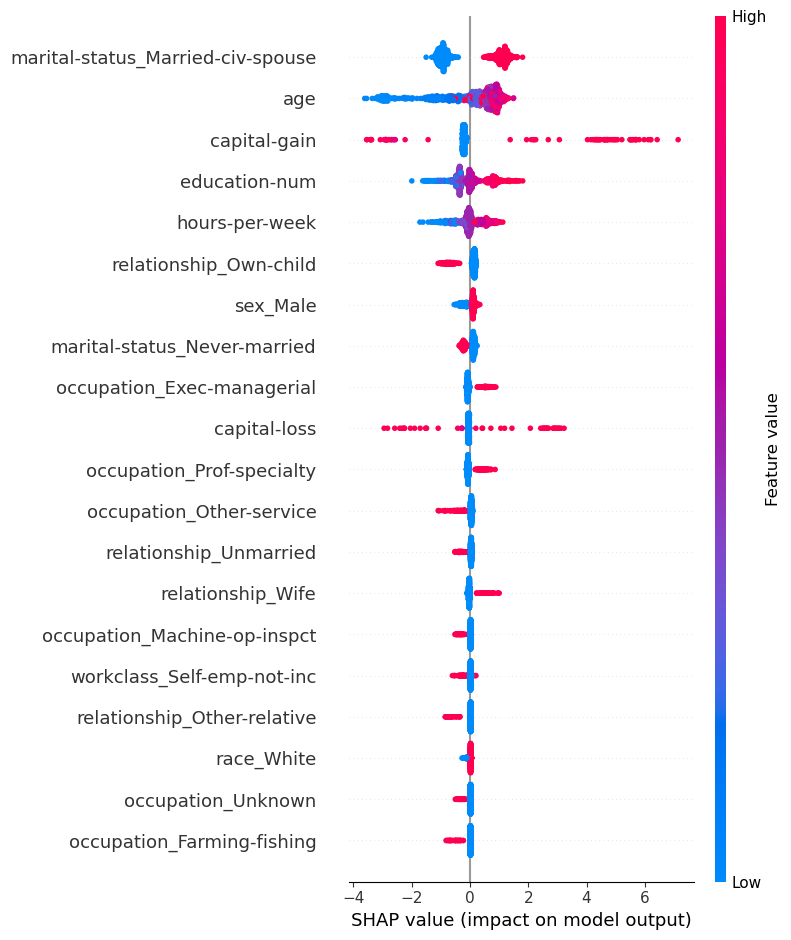

In [94]:
import shap

X_shap = X_test_c.sample(min(1000, len(X_test_c)), random_state=42)

explainer = shap.TreeExplainer(lgb_model_last)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
else:
    shap_to_plot = shap_values

shap.summary_plot(shap_to_plot, X_shap)

## Analysis & Conclusions

### Summary
We compared six methods on the UCI Adult Income binary classification task.

- **LightGBM** and **XGBoost** typically achieve top AUC-ROC on this dataset
  thanks to their ability to handle mixed numerical/categorical features.
- **FT-Transformer** leverages embeddings for categorical features, which can
  yield competitive AUC with sufficient training.
- **Logistic Regression** provides a fast and interpretable baseline.
- **TabNet** and **Random Forest** round out the comparison.

### Observations
- The dataset is moderately imbalanced (~24% positive); AUC-ROC is the most
  reliable metric here.
- OrdinalEncoding + StandardScaling is a straightforward preprocessing pipeline
  that works across all methods.
- 3-seed evaluation reveals model stability under random initialization.

### Next Steps
- One-hot encoding for tree methods vs. ordinal for neural methods. /
- Class-weight adjustment to improve F1 for the minority class.
- SHAP explanations for the best-performing model. /
